# Using Sentinel Hub Process API in EDC: a starter's guide.
---
Source: [Sentinel Hub Python package documentation](https://sentinelhub-py.readthedocs.io/en/latest/index.html)

## Getting started with `sentinelhub-py`

In this demonstration Jupyter Notebook, we will be requesting and exporting analysis-ready Earth Observation data with the Sentinel Hub [Process API](https://docs.sentinel-hub.com/api/latest/api/process/) using the dedicated [sentinelhub-py package](https://sentinelhub-py.readthedocs.io/en/latest/index.html) in the EDC EOxHub Workplace. In this notebook we will learn how to:

- [Request a true color (PNG) image on a specific date](#Example-1:-Request-a-true-color-(PNG)-image-on-a-specific-date)
  - [Add cloud mask data to the request](#Example-1.1-Adding-cloud-mask-data)
- [Request a true color mosaic of least cloudy acquisitions](#Example-2:-Request-a-true-color-mosaic-of-least-cloudy-acquisitions)
- [Request all Sentinel-2's raw band values](#Example-3:-Request-all-Sentinel-2's-raw-band-values)
- [Save downloaded data to disk and read it from disk](#Example-4:-Save-downloaded-data-to-disk-and-read-it-from-disk)
  - [Save downloaded data directly to disk](#Example-4.1:-Save-downloaded-data-directly-to-disk)
- [Request other data collections supported by sentinelhub-py](#Example-5:-Request-other-data-collections-supported-by-sh-py)
- [Perform a multi-response request](#Example-6:-Multi-response-request)
- [Request with a raw dictionary](#Example-7:-Request-with-a-raw-dictionary)
- [Request multiple timestamps data](#Example-8:-Request-multiple-timestamps-data)

## Prerequisites

Before acccessing the data, we will start by importing the necessary Python libraries (already configured in your EDC workspace), generate credentials automatically to access the services and define the `plot_image` function that can be found in the `utils.py` [file](https://github.com/sentinel-hub/sentinelhub-py/blob/master/examples/utils.py) located in Sentinel Hub's [GitHub repository](https://github.com/sentinel-hub/sentinelhub-py).

#### Imports

In [2]:
# Utilities
import os
import datetime
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Image

# Sentinel Hub
from sentinelhub import (MimeType, CRS, BBox, SentinelHubRequest, SentinelHubDownloadClient, 
                         DataCollection, bbox_to_dimensions, DownloadRequest, SHConfig)

#### Credentials

Credentials for Sentinel Hub services are automatically injected as environement variables. It is therefore easy to populate Sentinel Hub's credential manager with the values.

In [3]:
# Pass Sentinel Hub credentials to SHConfig
config = SHConfig()
config.sh_client_id = os.environ["SH_CLIENT_ID"]
config.sh_client_secret = os.environ["SH_CLIENT_SECRET"]

#### Utility function for plotting images

In the following cell, we define the `plot_image` function which will be used to display the requested images for all examples demonstrated in this notebook.

In [4]:
# Define the plot_image function
def plot_image(image, factor=1.0, clip_range = None, **kwargs):
    """
    Utility function for plotting RGB images.
    """
    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(15, 15))
    if clip_range is not None:
        ax.imshow(np.clip(image * factor, *clip_range), **kwargs)
    else:
        ax.imshow(image * factor, **kwargs)
    ax.set_xticks([])
    ax.set_yticks([])

In [5]:
# Configure plots for inline use in Jupyter Notebook
%matplotlib inline

## Setting area of interest (AOI)

We will download Sentinel-2 imagery of [Betsiboka Estuary](https://en.wikipedia.org/wiki/Betsiboka_River) such as the one shown below (taken by Sentinel-2 on 2017-12-15):

![Betsiboka Estuary](https://sentinelhub-py.readthedocs.io/en/latest/_images/wms_TRUE_COLOR_EPSG4326_-16.15_46.16_-15.58_46.51_2017-12-15T07-12-03_512X856.png)

The bounding box in `WGS84` coordinate system is `[46.16, -16.15, 46.51, -15.58]` (longitude and latitude coordinates of lower left and upper right corners). You can get the bbox for a different area at the [bboxfinder](http://bboxfinder.com/) website.

All requests require bounding box to be given as an instance of `sentinelhub.geometry.BBox` with corresponding Coordinate Reference System (`sentinelhub.constants.CRS`). In our case it is in WGS84 and we can use the predefined WGS84 coordinate reference system from `sentinelhub.constants.CRS`.

In [6]:
betsiboka_coords_wgs84 = [46.16, -16.15, 46.51, -15.58]

When the bounding box bounds have been defined, you can initialize the BBox of the area of interest. Using the bbox_to_dimensions utility function, you can provide the desired resolution parameter of the image in meters and obtain the output image shape.

In [7]:
resolution = 60
betsiboka_bbox = BBox(bbox=betsiboka_coords_wgs84, crs=CRS.WGS84)
betsiboka_size = bbox_to_dimensions(betsiboka_bbox, resolution=resolution)

print(f'Image shape at {resolution} m resolution: {betsiboka_size} pixels')

Image shape at 60 m resolution: (631, 1047) pixels


## Example 1: Request a true color (PNG) image on a specific date

We build the request according to the [API Reference](https://docs.sentinel-hub.com/api/latest/reference/), using the `SentinelHubRequest` class. Each Process API request also needs an [evalscript](https://docs.sentinel-hub.com/api/latest/#/Evalscript/V3/README).

The information that we specify in the `SentinelHubRequest` object is:
- an evalscript,
- a list of input data collections with time interval,
- a format of the response,
- a bounding box and it’s size (size or resolution).

The evalscript in the example is used to select the appropriate bands. We return the RGB (B04, B03, B02) Sentinel-2 L1C bands.

The image from Jun 12th 2020 is downloaded. Without any additional parameters in the evalscript, the downloaded data will correspond to reflectance values in `UINT8` format (values in 0-255 range).

In [8]:
evalscript_true_color = """
    //VERSION=3

    function setup() {
        return {
            input: [{
                bands: ["B02", "B03", "B04"]
            }],
            output: {
                bands: 3
            }
        };
    }

    function evaluatePixel(sample) {
        return [sample.B04, sample.B03, sample.B02];
    }
"""

request_true_color = SentinelHubRequest(
    evalscript=evalscript_true_color,
    input_data=[
        SentinelHubRequest.input_data(
            data_collection=DataCollection.SENTINEL2_L1C,
            time_interval=('2020-06-12', '2020-06-13'),
        )
    ],
    responses=[
        SentinelHubRequest.output_response('default', MimeType.PNG)
    ],
    bbox=betsiboka_bbox,
    size=betsiboka_size,
    config=config
)

In [9]:
true_color_imgs = request_true_color.get_data()

The method `get_data()` will always return a list of length 1 with the available image from the requested time interval in the form of numpy arrays.

In [10]:
print(f'Returned data is of type = {type(true_color_imgs)} and length {len(true_color_imgs)}.')
print(f'Single element in the list is of type {type(true_color_imgs[-1])} and has shape {true_color_imgs[-1].shape}')

Returned data is of type = <class 'list'> and length 1.
Single element in the list is of type <class 'numpy.ndarray'> and has shape (1047, 631, 3)


Image type: uint8


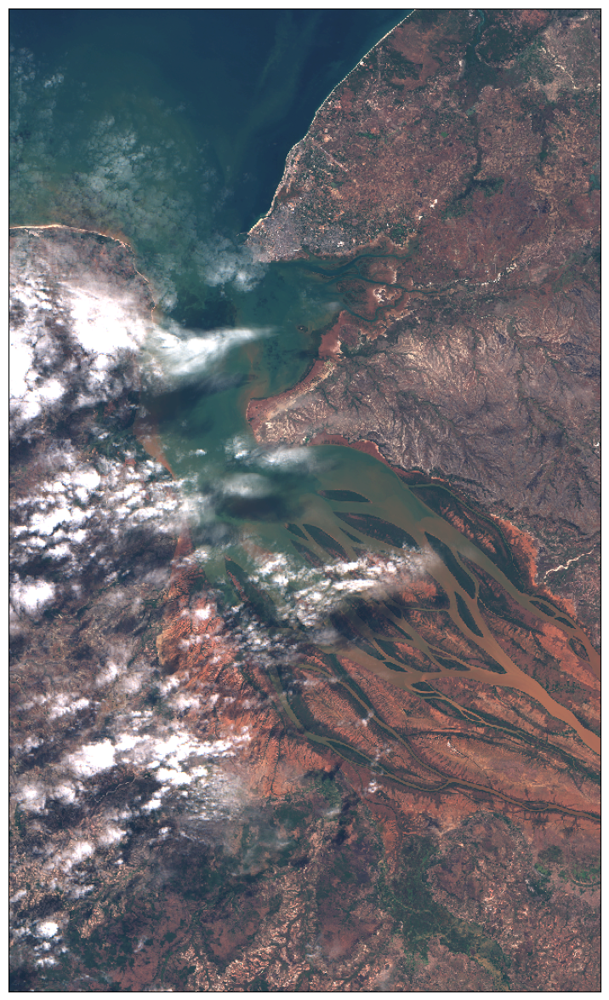

In [11]:
image = true_color_imgs[0]
print(f'Image type: {image.dtype}')

# plot function
# factor 1/255 to scale between 0-1
# factor 3.5 to increase brightness
plot_image(image, factor=3.5/255, clip_range=(0,1))

### Example 1.1 Adding cloud mask data

It is also possible to obtain cloud masks when requesting Sentinel-2 data by using the cloud mask band (`CLM`) or the cloud probabilities band (`CLP`). More info [here](https://docs.sentinel-hub.com/api/latest/#/API/data_access?id=cloud-masks-and-cloud-probabilities).

The factor for increasing the image brightness can already be provided in the evalscript.

In [12]:
evalscript_clm = """
//VERSION=3
function setup() {
  return {
    input: ["B02", "B03", "B04", "CLM"],
    output: { bands: 3 }
  }
}

function evaluatePixel(sample) {
  if (sample.CLM == 1) {
    return [0.75 + sample.B04, sample.B03, sample.B02]
  }
  return [3.5*sample.B04, 3.5*sample.B03, 3.5*sample.B02];
}
"""

request_true_color = SentinelHubRequest(
    evalscript=evalscript_clm,
    input_data=[
        SentinelHubRequest.input_data(
            data_collection=DataCollection.SENTINEL2_L1C,
            time_interval=('2020-06-12', '2020-06-13'),
        )
    ],
    responses=[
        SentinelHubRequest.output_response('default', MimeType.PNG)
    ],
    bbox=betsiboka_bbox,
    size=betsiboka_size,
    config=config
)

In [13]:
data_with_cloud_mask = request_true_color.get_data()

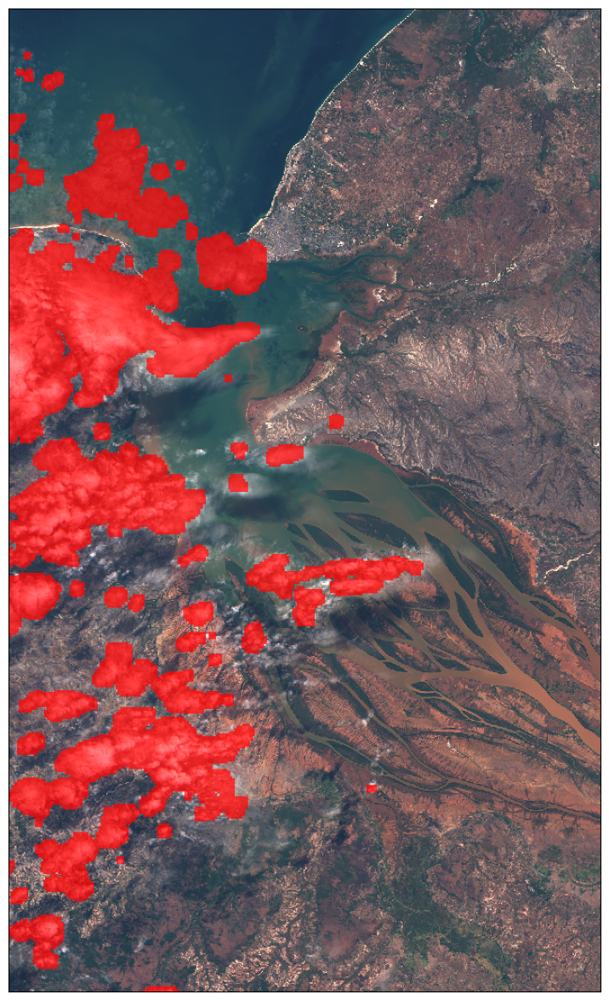

In [14]:
plot_image(data_with_cloud_mask[0], factor=1/255)

## Example 2: Request a true color mosaic of least cloudy acquisitions

The `SentinelHubRequest` automatically creates a mosaic from all available images in the given time interval. By default, the `mostRecent` mosaicking order is used. More information available [here](https://docs.sentinel-hub.com/api/latest/#/data/Sentinel-2-L2A?id=mosaickingorder).

In this example we will provide a month long interval, order the images w.r.t. the cloud coverage on the tile level (`leastCC` parameter), and mosaic them in the specified order.

In [15]:
request_true_color = SentinelHubRequest(
    evalscript=evalscript_true_color,
    input_data=[
        SentinelHubRequest.input_data(
            data_collection=DataCollection.SENTINEL2_L1C,
            time_interval=('2020-06-01', '2020-06-30'),
            mosaicking_order='leastCC'
        )
    ],
    responses=[
        SentinelHubRequest.output_response('default', MimeType.PNG)
    ],
    bbox=betsiboka_bbox,
    size=betsiboka_size,
    config=config
)

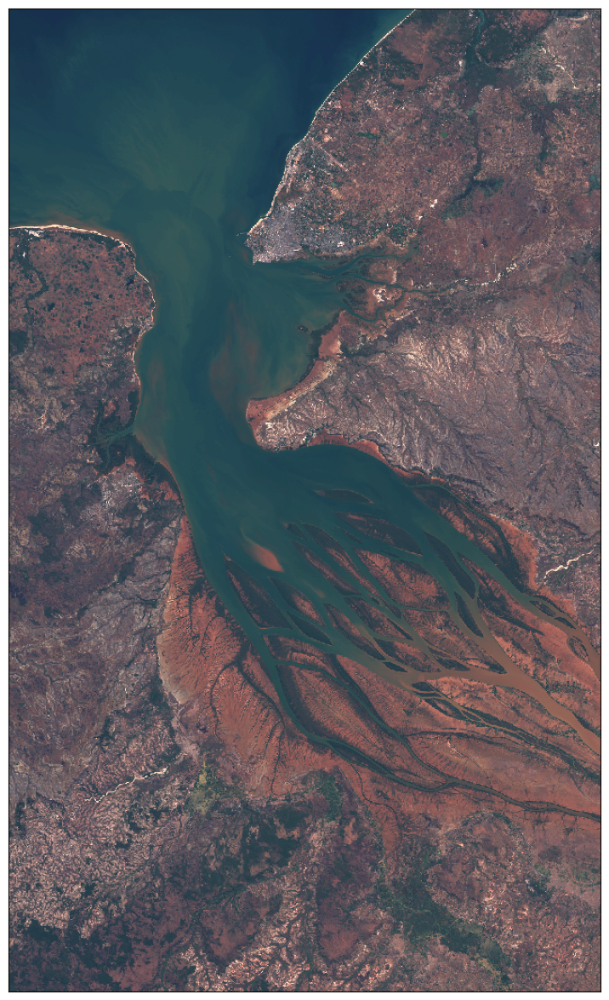

In [16]:
plot_image(request_true_color.get_data()[0], factor=3.5/255, clip_range=(0,1))

## Example 3: Request all Sentinel-2's raw band values

Now let’s define an evalscript which will return all Sentinel-2 spectral bands with raw values.

In this example we are downloading already quite a big chunk of data, so optimization of the request is not out of the question. Downloading raw digital numbers in the `INT16` format instead of reflectances in the `FLOAT32` format means that much less data is downloaded, which results in a faster download and a smaller usage of SH processing units.

In order to achieve this, we have to set the input units in the evalscript to `DN` (digital numbers) and the output `sampleType` argument to `INT16`. Additionally, we can’t pack all Sentinel-2’s 13 bands into a `PNG` image, so we have to set the output image type to the `TIFF` format via `MimeType.TIFF` in the request.

The digital numbers are in the range from 0-10000, so we have to scale the downloaded data appropriately.

In [17]:
evalscript_all_bands = """
    //VERSION=3
    function setup() {
        return {
            input: [{
                bands: ["B01","B02","B03","B04","B05","B06","B07","B08","B8A","B09","B10","B11","B12"],
                units: "DN"
            }],
            output: {
                bands: 13,
                sampleType: "INT16"
            }
        };
    }

    function evaluatePixel(sample) {
        return [sample.B01,
                sample.B02,
                sample.B03,
                sample.B04,
                sample.B05,
                sample.B06,
                sample.B07,
                sample.B08,
                sample.B8A,
                sample.B09,
                sample.B10,
                sample.B11,
                sample.B12];
    }
"""

request_all_bands = SentinelHubRequest(
    evalscript=evalscript_all_bands,
    input_data=[
        SentinelHubRequest.input_data(
            data_collection=DataCollection.SENTINEL2_L1C,
            time_interval=('2020-06-01', '2020-06-30'),
            mosaicking_order='leastCC'
    )],
    responses=[
        SentinelHubRequest.output_response('default', MimeType.TIFF)
    ],
    bbox=betsiboka_bbox,
    size=betsiboka_size,
    config=config
)

In [18]:
all_bands_response = request_all_bands.get_data()

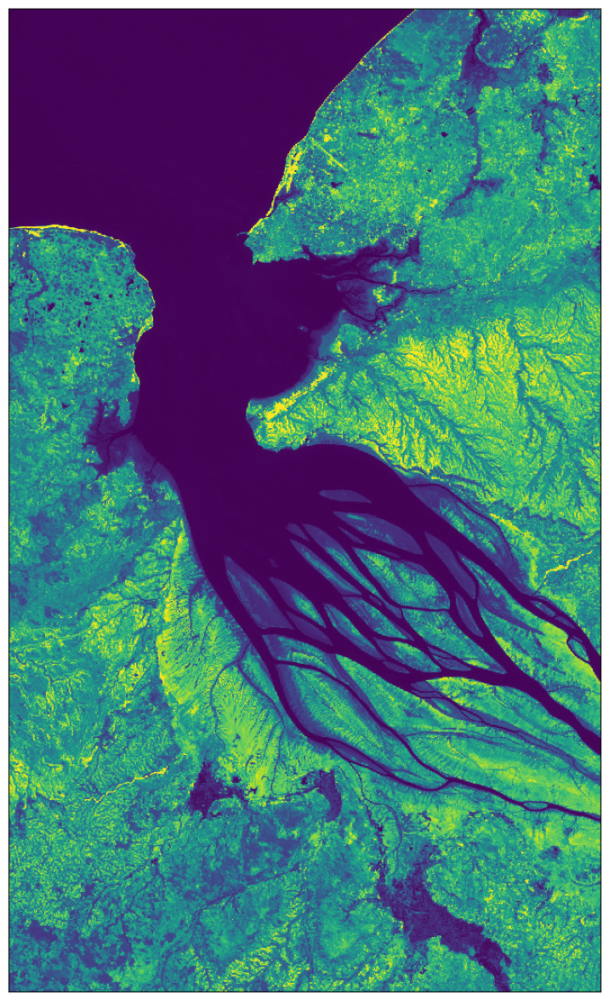

In [19]:
# Image showing the SWIR band B12
# Factor 1/1e4 due to the DN band values in the range 0-10000
# Factor 3.5 to increase the brightness
plot_image(all_bands_response[0][:, :, 12], factor=3.5/1e4, vmax=1)

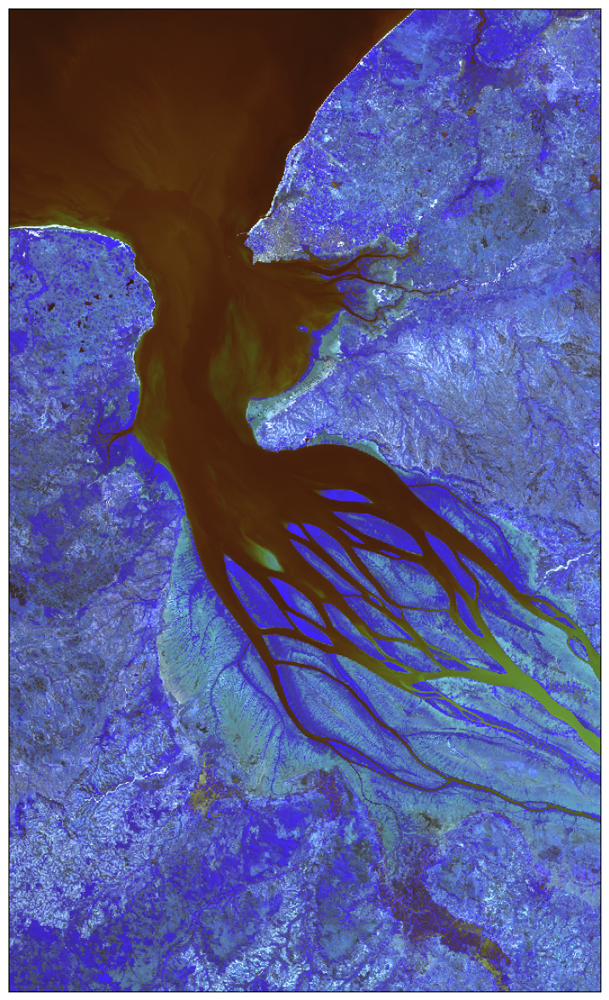

In [20]:
# From raw bands we can also construct a False-Color image
# False color image is (B03, B04, B08)
plot_image(all_bands_response[0][:, :, [2,3,7]], factor=3.5/1e4, clip_range=(0,1))

## Example 4: Save downloaded data to disk and read it from disk

All downloaded data can be saved to disk and later read from it. Simply specify the location on disk where data should be saved (or loaded from) via the `data_folder` argument of the request’s constructor. When executing the request’s `get_data` method, set the argument `save_data` to `True`.

This also means that in all the future requests for data, the request will first check the provided location if the data is already there, unless you explicitly demand to redownload the data.

In [21]:
request_all_bands = SentinelHubRequest(
    data_folder='test_dir',
    evalscript=evalscript_all_bands,
    input_data=[
        SentinelHubRequest.input_data(
            data_collection=DataCollection.SENTINEL2_L1C,
            time_interval=('2020-06-01', '2020-06-30'),
            mosaicking_order='leastCC'
    )],
    responses=[
        SentinelHubRequest.output_response('default', MimeType.TIFF)
    ],
    bbox=betsiboka_bbox,
    size=betsiboka_size,
    config=config
)

In [22]:
%%time
all_bands_img = request_all_bands.get_data(save_data=True)

CPU times: user 96.5 ms, sys: 31.3 ms, total: 128 ms
Wall time: 3.7 s


In [23]:
print(f'The output directory has been created and a tiff file with all 13 bands was saved into ' \
      'the following structure:\n')

for folder, _, filenames in os.walk(request_all_bands.data_folder):
    for filename in filenames:
        print(os.path.join(folder, filename))

The output directory has been created and a tiff file with all 13 bands was saved into the following structure:

test_dir/4d34ca44cf5505abbf2690c928df83fe/request.json
test_dir/4d34ca44cf5505abbf2690c928df83fe/response.tiff


In [24]:
%%time
# try to re-download the data
all_bands_img_from_disk = request_all_bands.get_data()

CPU times: user 72.4 ms, sys: 22.7 ms, total: 95.1 ms
Wall time: 60.5 ms


In [25]:
%%time
# force the redownload
all_bands_img_redownload = request_all_bands.get_data(redownload=True)

CPU times: user 100 ms, sys: 17.1 ms, total: 118 ms
Wall time: 3.72 s


### Example 4.1: Save downloaded data directly to disk

The `get_data` method returns a list of numpy arrays and can save the downloaded data to disk, as we have seen in the previous example. Sometimes it is convenient to just save the data directly to disk. You can do that by using `save_data` method instead.

In [26]:
%%time
request_all_bands.save_data()

CPU times: user 147 μs, sys: 1.04 ms, total: 1.19 ms
Wall time: 832 μs


In [27]:
print(f'The output directory has been created and a tiff file with all 13 bands was saved into ' \
      'the following structure:\n')

for folder, _, filenames in os.walk(request_all_bands.data_folder):
    for filename in filenames:
        print(os.path.join(folder, filename))

The output directory has been created and a tiff file with all 13 bands was saved into the following structure:

test_dir/4d34ca44cf5505abbf2690c928df83fe/request.json
test_dir/4d34ca44cf5505abbf2690c928df83fe/response.tiff


## Example 5: Request other data collections supported by `sh-py`

The `sentinelhub-py` package supports various data collections. The example below is shown for one of them, but the process is the same for all of them.

**Note: For more examples and information check the [tutorial about data collections](https://sentinelhub-py.readthedocs.io/en/latest/examples/data_collections.html) and [Sentinel Hub documentation about data collections](https://docs.sentinel-hub.com/api/latest/#/data/).**

In [28]:
print('Supported DataCollections:\n')
for collection in DataCollection.get_available_collections():
    print(collection)

Supported DataCollections:

DataCollection.SENTINEL2_L1C
DataCollection.SENTINEL2_L2A
DataCollection.SENTINEL1
DataCollection.SENTINEL1_IW
DataCollection.SENTINEL1_IW_ASC
DataCollection.SENTINEL1_IW_DES
DataCollection.SENTINEL1_EW
DataCollection.SENTINEL1_EW_ASC
DataCollection.SENTINEL1_EW_DES
DataCollection.SENTINEL1_EW_SH
DataCollection.SENTINEL1_EW_SH_ASC
DataCollection.SENTINEL1_EW_SH_DES
DataCollection.DEM
DataCollection.DEM_MAPZEN
DataCollection.DEM_COPERNICUS_30
DataCollection.DEM_COPERNICUS_90
DataCollection.MODIS
DataCollection.LANDSAT_MSS_L1
DataCollection.LANDSAT_TM_L1
DataCollection.LANDSAT_TM_L2
DataCollection.LANDSAT_ETM_L1
DataCollection.LANDSAT_ETM_L2
DataCollection.LANDSAT_OT_L1
DataCollection.LANDSAT_OT_L2
DataCollection.SENTINEL5P
DataCollection.SENTINEL3_OLCI
DataCollection.SENTINEL3_SLSTR
DataCollection.HARMONIZED_LANDSAT_SENTINEL


For this example let’s download the digital elevation model data (DEM). The process is similar as before, we just provide the evalscript and create the request. More data on the `DEM` data collection is available [here](https://docs.sentinel-hub.com/api/latest/#/data/DEM). `DEM` values are in meters and can be negative for areas which lie below sea level, so it is recommended to set the output format in your evalscript to `FLOAT32`.

In [29]:
evalscript_dem = '''
//VERSION=3
function setup() {
  return {
    input: ["DEM"],
    output:{
      id: "default",
      bands: 1,
      sampleType: SampleType.FLOAT32
    }
  }
}

function evaluatePixel(sample) {
  return [sample.DEM]
}
'''

In [30]:
dem_request = SentinelHubRequest(
    evalscript=evalscript_dem,
    input_data=[
        SentinelHubRequest.input_data(
            data_collection=DataCollection.DEM,
            time_interval=('2020-06-12', '2020-06-13'),
    )
    ],
    responses=[
        SentinelHubRequest.output_response('default', MimeType.TIFF)
    ],
    bbox=betsiboka_bbox,
    size=betsiboka_size,
    config=config
)

In [31]:
dem_data = dem_request.get_data()

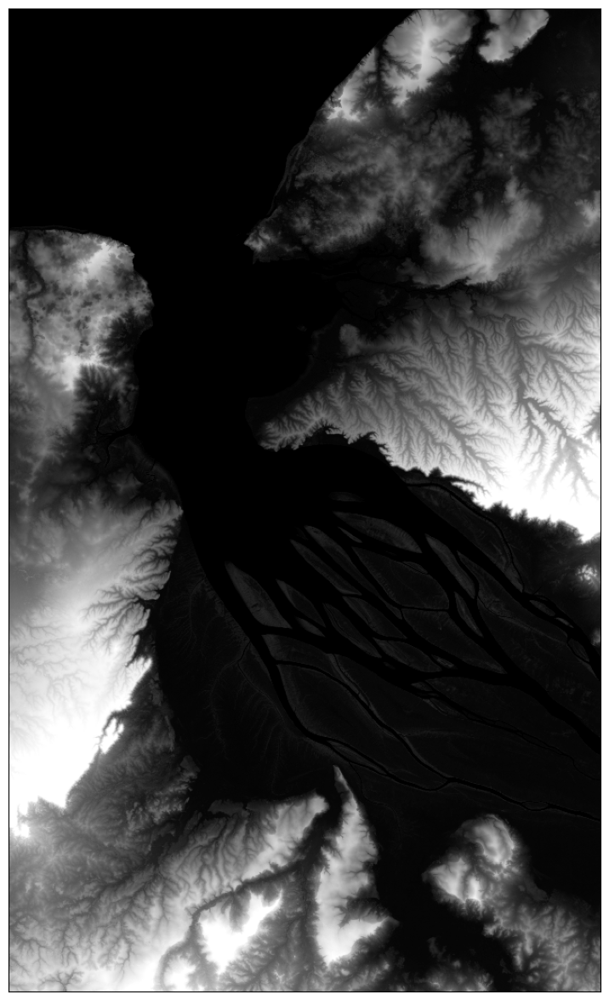

In [32]:
# Plot DEM map
# vmin = 0; cutoff at sea level (0 m)
# vmax = 120; cutoff at high values (120 m)
plot_image(dem_data[0], factor=1.0, cmap=plt.cm.Greys_r, vmin=0, vmax=120)

## Example 6: Multi-response request

Process API enables downloading multiple files in one response, packed together in a TAR archive.

We will get the same image as before, download in the form of digital numbers (DN) as a UINT16 TIFF file. Along with the image we will download the `inputMetadata` which contains the normalization factor value in a JSON format.

After the download we will be able to convert the `INT16` digital numbers to get the `FLOAT32` reflectances.

In [33]:
evalscript = """
    //VERSION=3

    function setup() {
        return {
            input: [{
                bands: ["B02", "B03", "B04"],
                units: "DN"
            }],
            output: {
                bands: 3,
                sampleType: "INT16"
            }
        };
    }

    function updateOutputMetadata(scenes, inputMetadata, outputMetadata) {
        outputMetadata.userData = { "norm_factor":  inputMetadata.normalizationFactor }
    }

    function evaluatePixel(sample) {
        return [sample.B04, sample.B03, sample.B02];
    }
"""

request_multitype = SentinelHubRequest(
    evalscript=evalscript,
    input_data=[
        SentinelHubRequest.input_data(
            data_collection=DataCollection.SENTINEL2_L1C,
            time_interval=('2020-06-01', '2020-06-30'),
            mosaicking_order='leastCC'
        )
    ],
    responses=[
        SentinelHubRequest.output_response('default', MimeType.TIFF),
        SentinelHubRequest.output_response('userdata', MimeType.JSON)
    ],
    bbox=betsiboka_bbox,
    size=betsiboka_size,
    config=config
)

In [34]:
# print out information
multi_data = request_multitype.get_data()[0]
multi_data.keys()

dict_keys(['default.tif', 'userdata.json'])

In [35]:
# normalize image
img = multi_data['default.tif']
norm_factor = multi_data['userdata.json']['norm_factor']

img_float32 = img * norm_factor

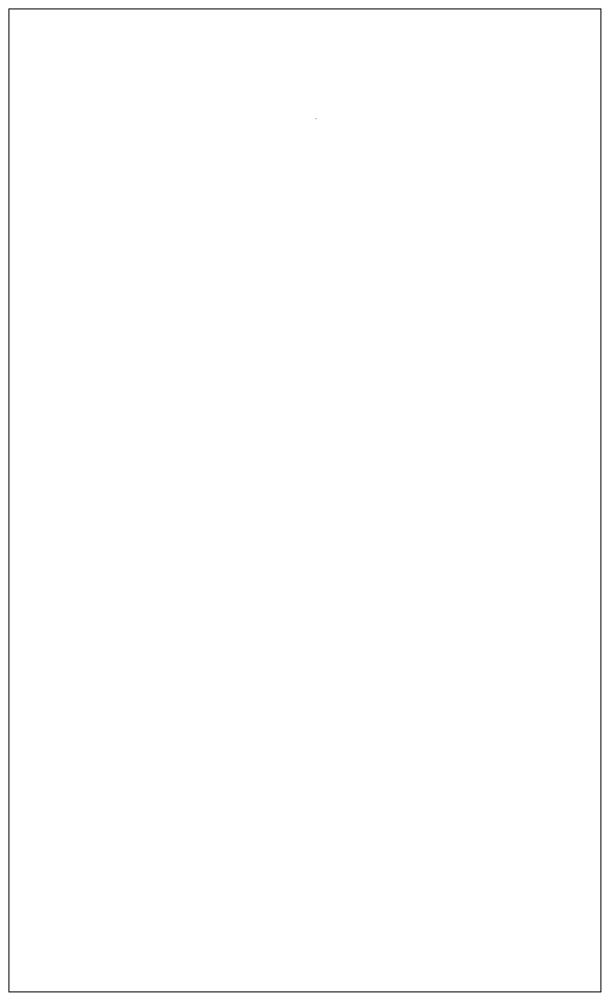

In [36]:
plot_image(img_float32, factor=3.5, clip_range=(0, 1))

## Example 7: Request with a raw dictionary

All requests so far were built with some helper functions. We can also construct a raw dictionary as defined in the [API Reference](https://docs.sentinel-hub.com/api/latest/reference/), without these helper functions, so we have full control over building the request body.

In [37]:
request_raw_dict = {
    "input": {
        "bounds": {
            "properties": {
                "crs": betsiboka_bbox.crs.opengis_string
            },
            "bbox": list(betsiboka_bbox)
        },
        "data": [
            {
                "type": "S2L1C",
                "dataFilter": {
                    "timeRange": {"from": '2020-06-01T00:00:00Z', "to": '2020-06-30T00:00:00Z'},
                    "mosaickingOrder": "leastCC",
                }
            }
        ]
    },
    "output": {
        "width": betsiboka_size[0],
        "height": betsiboka_size[1],
        "responses": [
            {
                "identifier": "default",
                "format": {
                    'type': MimeType.TIFF.get_string()
                }
            }
        ]
    },
    "evalscript": evalscript_true_color
}

In [39]:
# create request
download_request = DownloadRequest(
    request_type='POST',
    url="https://services.sentinel-hub.com/api/v1/process",
    post_values=request_raw_dict,
    data_type=MimeType.TIFF,
    headers={'content-type': 'application/json'},
    use_session=True
)

# execute request
client = SentinelHubDownloadClient(config=config)
img = client.download(download_request)

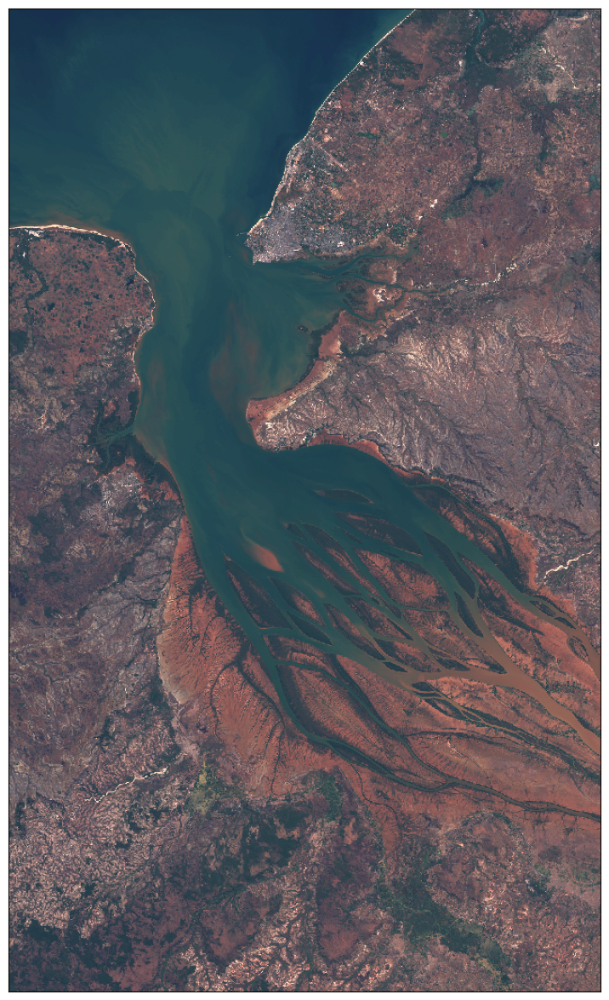

In [40]:
plot_image(img, factor=3.5/255, clip_range=(0,1))

## Example 8: Request multiple timestamps data

It is possible to construct some logic in order to return data for multiple timestamps. By defining the `time_interval` parameter and some logic of splitting it, it is possible to create an SH reques per each “time slot” and then download the data from all the requests with the `SentinelHubDownloadClient` in `sentinelhub-py`. In this example we will create least cloudy monthly images for the year 2019.

However, this is already a functionality built on top of this SH API package. We have extended the support for such usage in our package [eo-learn](https://github.com/sentinel-hub/eo-learn). We recommend to use `eo-learn` for more complex cases where you need multiple timestamps or high-resolution data for larger areas.

In [41]:
start = datetime.datetime(2019,1,1)
end = datetime.datetime(2019,12,31)
n_chunks = 13
tdelta = (end - start) / n_chunks
edges = [(start + i*tdelta).date().isoformat() for i in range(n_chunks)]
slots = [(edges[i], edges[i+1]) for i in range(len(edges)-1)]

print('Monthly time windows:\n')
for slot in slots:
    print(slot)

Monthly time windows:

('2019-01-01', '2019-01-29')
('2019-01-29', '2019-02-26')
('2019-02-26', '2019-03-26')
('2019-03-26', '2019-04-23')
('2019-04-23', '2019-05-21')
('2019-05-21', '2019-06-18')
('2019-06-18', '2019-07-16')
('2019-07-16', '2019-08-13')
('2019-08-13', '2019-09-10')
('2019-09-10', '2019-10-08')
('2019-10-08', '2019-11-05')
('2019-11-05', '2019-12-03')


In [42]:
def get_true_color_request(time_interval):
    return SentinelHubRequest(
        evalscript=evalscript_true_color,
        input_data=[
            SentinelHubRequest.input_data(
                data_collection=DataCollection.SENTINEL2_L1C,
                time_interval=time_interval,
                mosaicking_order='leastCC'
            )
        ],
        responses=[
            SentinelHubRequest.output_response('default', MimeType.PNG)
        ],
        bbox=betsiboka_bbox,
        size=betsiboka_size,
        config=config
    )

In [43]:
# create a list of requests
list_of_requests = [get_true_color_request(slot) for slot in slots]
list_of_requests = [request.download_list[0] for request in list_of_requests]

# download data with multiple threads
data = SentinelHubDownloadClient(config=config).download(list_of_requests, max_threads=5)

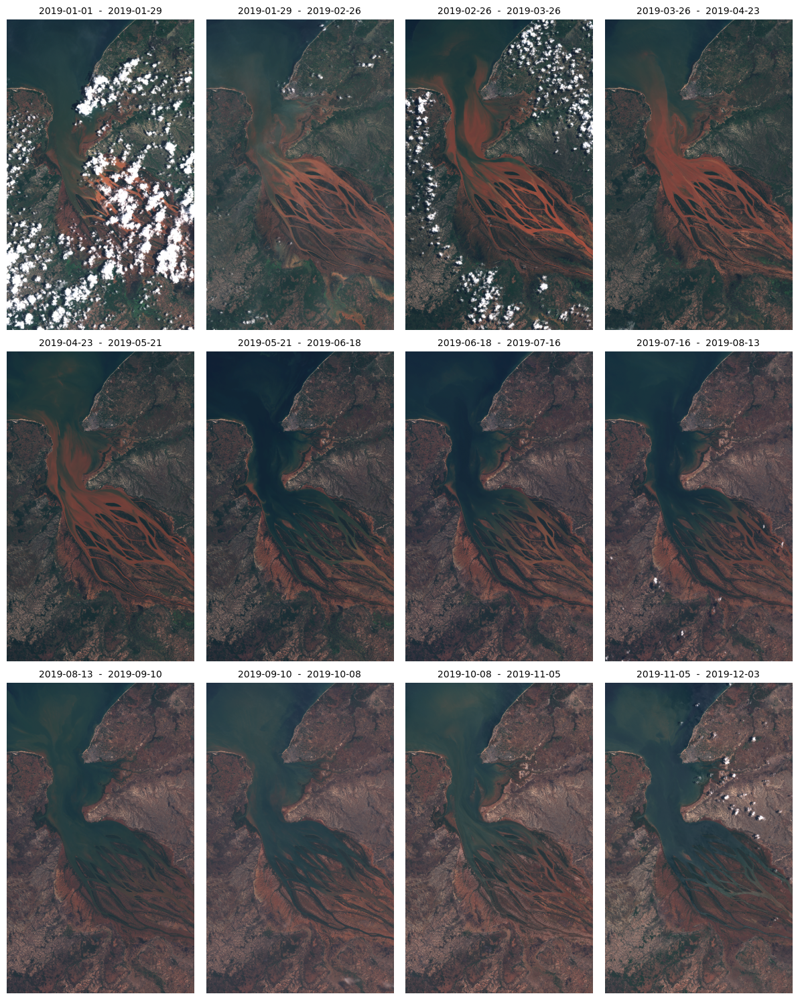

In [44]:
# some stuff for pretty plots
ncols = 4
nrows = 3
aspect_ratio = betsiboka_size[0] / betsiboka_size[1]
subplot_kw = {'xticks': [], 'yticks': [], 'frame_on': False}

fig, axs = plt.subplots(ncols=ncols, nrows=nrows, figsize=(5 * ncols * aspect_ratio, 5 * nrows),
                        subplot_kw=subplot_kw)

for idx, image in enumerate(data):
    ax = axs[idx // ncols][idx % ncols]
    ax.imshow(np.clip(image * 2.5/255, 0, 1))
    ax.set_title(f'{slots[idx][0]}  -  {slots[idx][1]}', fontsize=10)

plt.tight_layout()